In [1]:
using CMPSExcitations

In [2]:
# canonical basis
function projection_matrix1(D, R)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    Dr, M = eigen(R)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        dD1 = view(e, 1:D)
        dD2 = view(e, D+1:2*D)
        X = zeros(D, D)

        k = 2D + 1
        for i in 1:D, j in 1:D
            if i != j
                X[i, j] = e[k] # sets the one hot vector
                k += 1
            end
        end

        Dr = Diagonal(Dr)
        W1 = M * ((X * Dr - Dr * X) + Diagonal(dD1)) / M
        W2 = M * ((X * Dr - Dr * X) + Diagonal(dD2)) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q)
end

function projection_matrix2(D, R)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    Dr, M = eigen(R)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E - M * Diagonal(F) / M
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

function projection_matrix3(D, R, r)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    Dr, M = eigen(R)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E - M * Diagonal(F) / M / sqrt(r)
        W2 = E + M * Diagonal(F) / M / sqrt(r)

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

# canonical basis
function left2centre_matrix(ρR)
    D = size(ρR, 1)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR) # generally can be any C such that CC' = r

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        X1, X2 = W1 * factor, W2 * factor
        M[:, j] = vcat(vec(X1), vec(X2))
    end

    return M
end

left2centre_matrix (generic function with 1 method)

In [3]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

In [4]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
c, μ = 10., 5.
tol = 1e-10
Ds = [6]
D = maximum(Ds)

HLL = Hsingle(c, μ)
stateLL = find_groundstate(Ds, HLL, YangGaudinCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("------------")
HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=6


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

D = 6 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 11.066681 seconds (58.89 M allocations: 2.911 GiB, 2.17% gc time, 92.73% compilation time: <1% of which was recompilation)
---------------
Energy density: 

┌ Info: YangGaudinCMPS ground state: converged after 232 iterations: e = -2.757516806052, ‖∇e‖ = 5.5564e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


-2.757516806051871
 Particle density: 0.4359007920732793
 Order parameter: 0.3873412573405765
------------
Energy density: -2.7575168060518718
 Particle density: 0.43590079207327737
 Order parameter: 0.3873412573405776


In [5]:
function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

leftgaugetv (generic function with 1 method)

In [7]:
comm(A, B) = A * B - B * A

p = 1
ps = range(0, 5, 10)
vals = zeros(ComplexF64, length(ps))

for idx in eachindex(ps)
    p = ps[idx]
    ρR = rightenv(stateCLL)[1][]

    Q, R = stateCLL.Q[], stateCLL.Rs[1][]

    V, W1, W2 = zero(Q), R, -R
    V, W1, W2 = leftgaugetv(Q, R, V, W1, W2, p)

    space = InfiniteCMPSExcitationSpace(p, stateCLL, stateCLL)
    Heff = excitation_operator(HCLL, space)
    P = projection_matrix2(D, R)
    Hm = excitation_matrix(Heff, D)
    B = left2centre_matrix(ρR)
    Q = P * P'

    Hc = Q' * B' * Hm * B * Q
    res = Hc * vcat(vec(W1), vec(W2))
    HW1 = reshape(view(res, 1:D^2), D, D)
    HW2 = reshape(view(res, D^2+1:2*D^2), D, D)

    Nc = Q' * B' * B * Q
    res = Nc * vcat(vec(W1), vec(W2))
    HN1 = reshape(view(res, 1:D^2), D, D)
    HN2 = reshape(view(res, D^2+1:2*D^2), D, D)

    # (l|W ⊗ W̄|r)
    vals[idx] = tr(HW1 * ρR * W1' + HW2 * ρR * W2') 
    # / tr(W1 * ρR * W1' + W2 * ρR * W2') / tr(HN1 * ρR * W1' + HN2 * ρR * W2')
end

In [8]:
vals

10-element Vector{ComplexF64}:
  5.217395138048546 - 4.310474082231204e-15im
  5.261419948160736 - 0.13886393408825884im
  5.393494378497296 - 0.27772786817651324im
  5.613618429058232 - 0.41659180226476783im
  5.921792099843536 - 0.5554557363530225im
 6.3180153908532155 - 0.6943196704412775im
 6.8022883020872635 - 0.8331836045295326im
  7.374610833545691 - 0.972047538617789im
  8.034982985228497 - 1.1109114727060432im
  8.783404757135646 - 1.249775406794298im

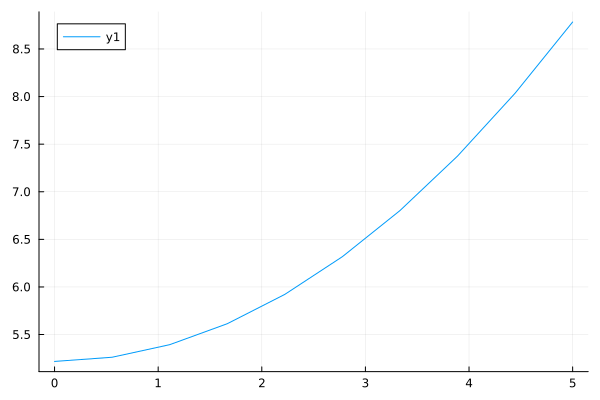

In [9]:
plot(ps, real(vals))